In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import  pickle as pkl


In [46]:
# Read in data files

#Water Quality
## NU YSI Locations
CalUnionDitch_data = pd.read_pickle("CalUnionDitch_C2H2_subset.pkl")
BelaireCreek_data = pd.read_pickle("BelaireCreek_C2H2_subset.pkl")
#South Holland not deployed yet

#No data available yet
# ##MWRD Locations
# Ashland_data = pd.read_pickle()
# Cicero_data = pd.read_pickle()
# IndianaHarbor_data = pd.read_pickle()
# Route83_data = pd.read_pickle()
# Halsted_data = pd.read_pickle()
# ##H2NOW Locations
# Diversion_data = pd.read_pickle()

#Other data
#Precipitation, from MRSM data 2min frequency intensity
precipitation_data = pd.read_pickle("Precipitation_C2H2_subset.pkl") #this is an average for the LCRW boundary
precipitation_data.index = precipitation_data.index.tz_convert('America/Chicago')
precipitation = precipitation_data.copy()
precipitation['precip_mm'] = precipitation['LCRW']/60

#Flow
flow_data = pd.read_pickle("Flow_C2H2_subset.pkl")
flow_data.index = pd.to_datetime(flow_data['datetime'])
flow_data = flow_data.set_index('datetime')

In [47]:
def plot_sites_timeseries_all(site_dfs, column, precip_df=None, flow_df=None, flow_sites=None, site_labels=None,
                              start_date=None, end_date=None):
    """
    Plots the same water quality variable from multiple site DataFrames on the same y-axis,
    with optional precipitation bars and site visit spans. Supports filtering by date range.
    Additionally, plots flow data for specified sites on a separate panel.

    Parameters:
        site_dfs (dict or list): Dictionary or list of site DataFrames with datetime indexes.
                                 If dict, keys will be used as labels unless `site_labels` is provided.
        column (str): The column to plot (e.g., 'TEMP °C').
        precip_df (pd.DataFrame, optional): Precipitation DataFrame with datetime index and 'precip_mm' column.
        flow_df (pd.DataFrame, optional): Flow DataFrame with datetime index and site columns.
        flow_sites (list of str, optional): List of flow sites (column names) to plot from flow_df.
        site_labels (list of str, optional): Custom labels for the sites (must match order of site_dfs if list).
        start_date (str or pd.Timestamp, optional): Start of the time window to plot.
        end_date (str or pd.Timestamp, optional): End of the time window to plot.
    """
    import matplotlib.pyplot as plt
    import pandas as pd

    # Create figure with two subplots (water quality on top, flow below)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})

    # Convert start/end to timezone-aware timestamps if provided
    if start_date:
        start_date = pd.to_datetime(start_date).tz_localize('America/Chicago', ambiguous='NaT', nonexistent='shift_forward')
    if end_date:
        end_date = pd.to_datetime(end_date).tz_localize('America/Chicago', ambiguous='NaT', nonexistent='shift_forward')

    # Determine if input is dict or list
    if isinstance(site_dfs, dict):
        sites = list(site_dfs.items())
    else:
        if site_labels is None:
            raise ValueError("If passing a list of DataFrames, you must provide site_labels.")
        sites = list(zip(site_labels, site_dfs))

    # Custom color map based on site names
    color_map = {
        "Indiana Harbor": "#c9d3de",  # Lightest blue
        "Halsted": "#9db8cc",
        "Diversion": "#4d7cad",
        "Cicero": "#35568d",
        "Route83": "#112033",        # Darker blue
        "Belaire Creek": "#7ed957",  # Green
        "CalUnionDitch": "#cc4e00",  # Red
        "Ashland": "#f6fb2f",        # Yellow
        "SouthHolland":  "#13b1ff",   # Orange
    }
    default_colors = plt.cm.tab10.colors  # Fallback colors

    # --- Plot water quality timeseries ---
    lines = []
    for i, (label, df) in enumerate(sites):
        if column not in df.columns:
            print(f"Skipping site '{label}': column '{column}' not found.")
            continue

        df_local = df.copy()
        try:
            if df_local.index.tz is None:
                df_local.index = df_local.index.tz_localize('America/Chicago', ambiguous='NaT', nonexistent='shift_forward')
            else:
                df_local.index = df_local.index.tz_convert('America/Chicago')
        except Exception as e:
            print(f"Skipping site '{label}': timezone localization/conversion failed with error: {e}")
            continue

        if start_date:
            df_local = df_local[df_local.index >= start_date]
        if end_date:
            df_local = df_local[df_local.index <= end_date]

        if df_local.empty:
            print(f"Skipping site '{label}': no data available in the specified date range.")
            continue

        plot_index = df_local.index.tz_localize(None)
        color = color_map.get(label, default_colors[i % len(default_colors)])
        line = ax1.plot(plot_index, df_local[column], label=label, color=color)
        lines += line

    # Add shaded site visit times on ax1
    shaded_times = [
        ('2025-08-21 09:08', '2025-08-21 10:37'),
        ('2025-08-21 06:00', '2025-08-21 16:00')
    ]
    for start_str, end_str in shaded_times:
        start_time = pd.to_datetime(start_str).tz_localize('America/Chicago', ambiguous='NaT', nonexistent='shift_forward')
        end_time = pd.to_datetime(end_str).tz_localize('America/Chicago', ambiguous='NaT', nonexistent='shift_forward')
        if (not start_date or end_time >= start_date) and (not end_date or start_time <= end_date):
            ax1.axvspan(start_time.tz_localize(None), end_time.tz_localize(None), color='darkblue', alpha=0.3)

    ax1.set_ylabel(column)
    ax1.set_title(f"{column} Over Time Across Sites")
    ax1.grid(True, color='lightgray')

    # Add precipitation on ax1 if available
    if precip_df is not None:
        precip_local = precip_df.copy()
        if precip_local.index.tz is None:
            precip_local.index = precip_local.index.tz_localize('America/Chicago', ambiguous='NaT', nonexistent='shift_forward')
        else:
            precip_local.index = precip_local.index.tz_convert('America/Chicago')

        if start_date:
            precip_local = precip_local[precip_local.index >= start_date]
        if end_date:
            precip_local = precip_local[precip_local.index <= end_date]

        ax1_precip = ax1.twinx()
        ax1_precip.bar(
            precip_local.index.tz_localize(None),
            precip_local['precip_mm'],
            width=pd.Timedelta(minutes=2),
            color='black',
            alpha=0.4,
            label='Precipitation'
        )
        ax1_precip.set_ylim(2, 0)
        ax1_precip.set_ylabel('Precipitation (mm)', color='black')
        ax1_precip.tick_params(axis='y', colors='black')
        ax1_precip.yaxis.set_label_position("right")
        ax1_precip.yaxis.tick_right()

        lines.append(plt.Line2D([0], [0], color='black', lw=4, alpha=0.4, label='Precipitation (mm)'))

    # --- Plot flow timeseries on ax2 ---
    if flow_df is not None and flow_sites is not None:
        flow_local = flow_df.copy()
        if flow_local.index.tz is None:
            flow_local.index = flow_local.index.tz_localize('America/Chicago', ambiguous='NaT', nonexistent='shift_forward')
        else:
            flow_local.index = flow_local.index.tz_convert('America/Chicago')

        if start_date:
            flow_local = flow_local[flow_local.index >= start_date]
        if end_date:
            flow_local = flow_local[flow_local.index <= end_date]

        flow_lines = []
        flow_colors = ['black', 'dimgray', 'lightgray']
        for i, site in enumerate(flow_sites):
            if site not in flow_local.columns:
                print(f"Skipping flow site '{site}': not found in flow_df columns.")
                continue
            data = flow_local[site].dropna()
            if data.empty:
                print(f"Skipping flow site '{site}': no data in specified date range.")
                continue
            flow_lines += ax2.plot(data.index.tz_localize(None), data, label=site, color=flow_colors[i % len(flow_colors)])

        ax2.set_ylabel("Flow (cfs)")  # Change units as appropriate
        ax2.set_xlabel("Date")
        ax2.grid(True, color='lightgray')
        ax2.legend(loc='upper right')
    else:
        ax2.set_visible(False)  # Hide flow panel if no flow_df provided

    # Combine legend for water quality + precip (not flow)
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

    fig.tight_layout()
    plt.show()

    return fig, (ax1, ax2)

In [48]:
site_names = [
    'Belaire Creek',
    'CalUnionDitch',
    'Route83',
    'Cicero',
    'Halsted',
    'Indiana Harbor',
    'Ashland',
    'Diversion',
    'SouthHolland'
]

site_dfs = {}

for site in site_names:
    # Convert to variable name style if needed, e.g. remove spaces or use underscores
    # Assuming your variables are named exactly like the site names but no spaces (or you can define a mapping)
    var_name = site.replace(" ", "").replace("-", "").replace("'", "") + "_data"
    if var_name in globals():
        site_dfs[site] = globals()[var_name]
    else:
        print(f"Skipping {site}: variable '{var_name}' not found")


Skipping Route83: variable 'Route83_data' not found
Skipping Cicero: variable 'Cicero_data' not found
Skipping Halsted: variable 'Halsted_data' not found
Skipping Indiana Harbor: variable 'IndianaHarbor_data' not found
Skipping Ashland: variable 'Ashland_data' not found
Skipping Diversion: variable 'Diversion_data' not found
Skipping SouthHolland: variable 'SouthHolland_data' not found


In [49]:
water_quality_parameters = ["SPCOND µS/CM", "FDOM RFU", "TEMP °C", "TURBIDITY FNU", "ODO MG/L"]

flow_sites_to_plot = ['LittleCal_SH','CalUnionDitch ','CalSag_H2NOW'] 


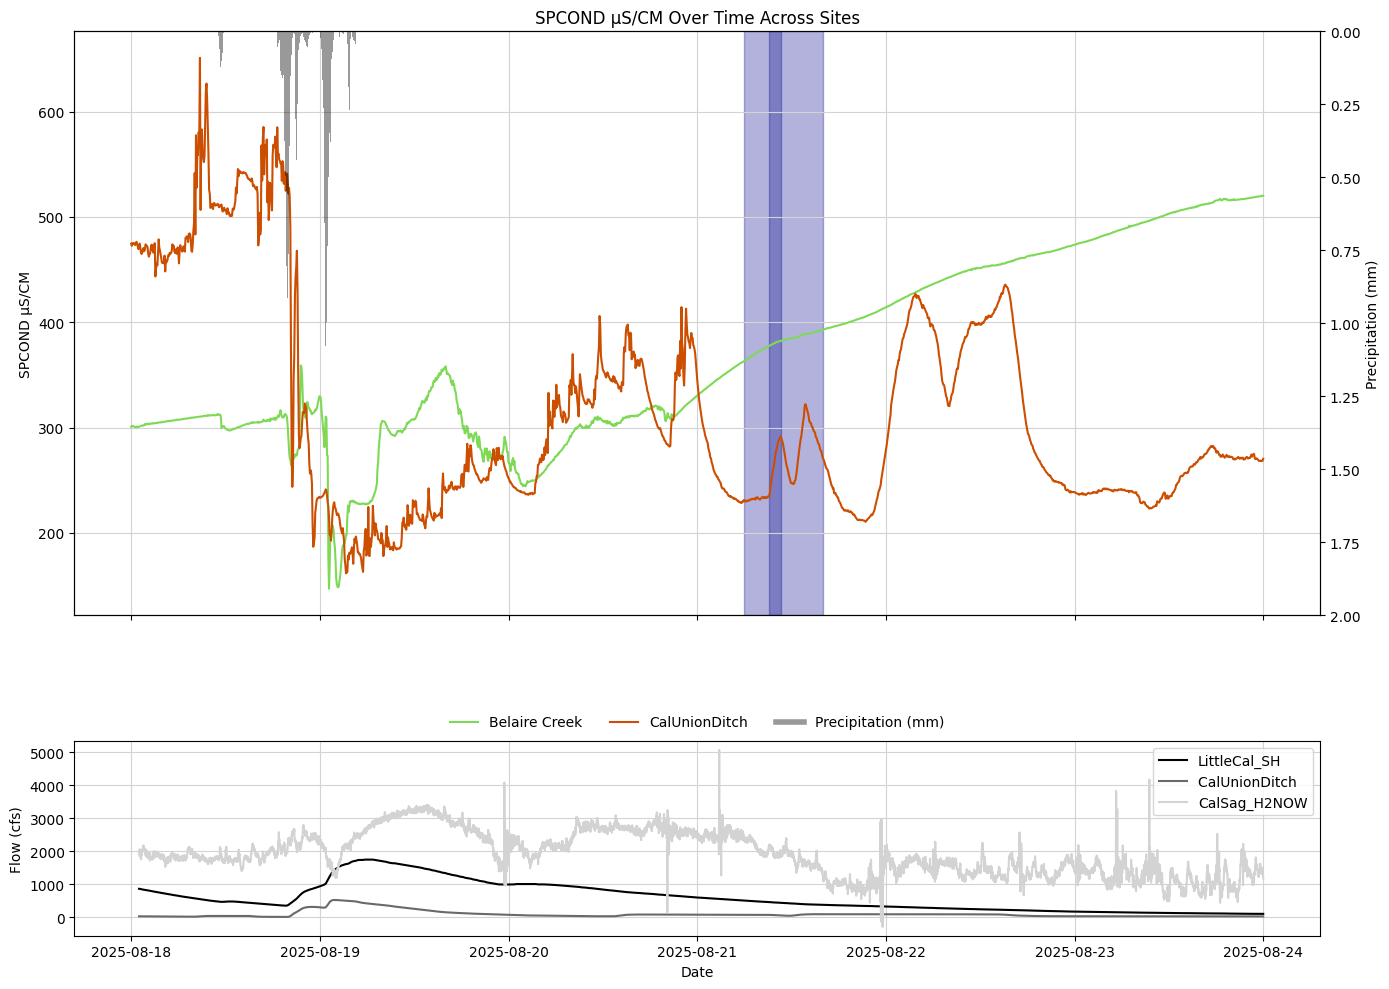

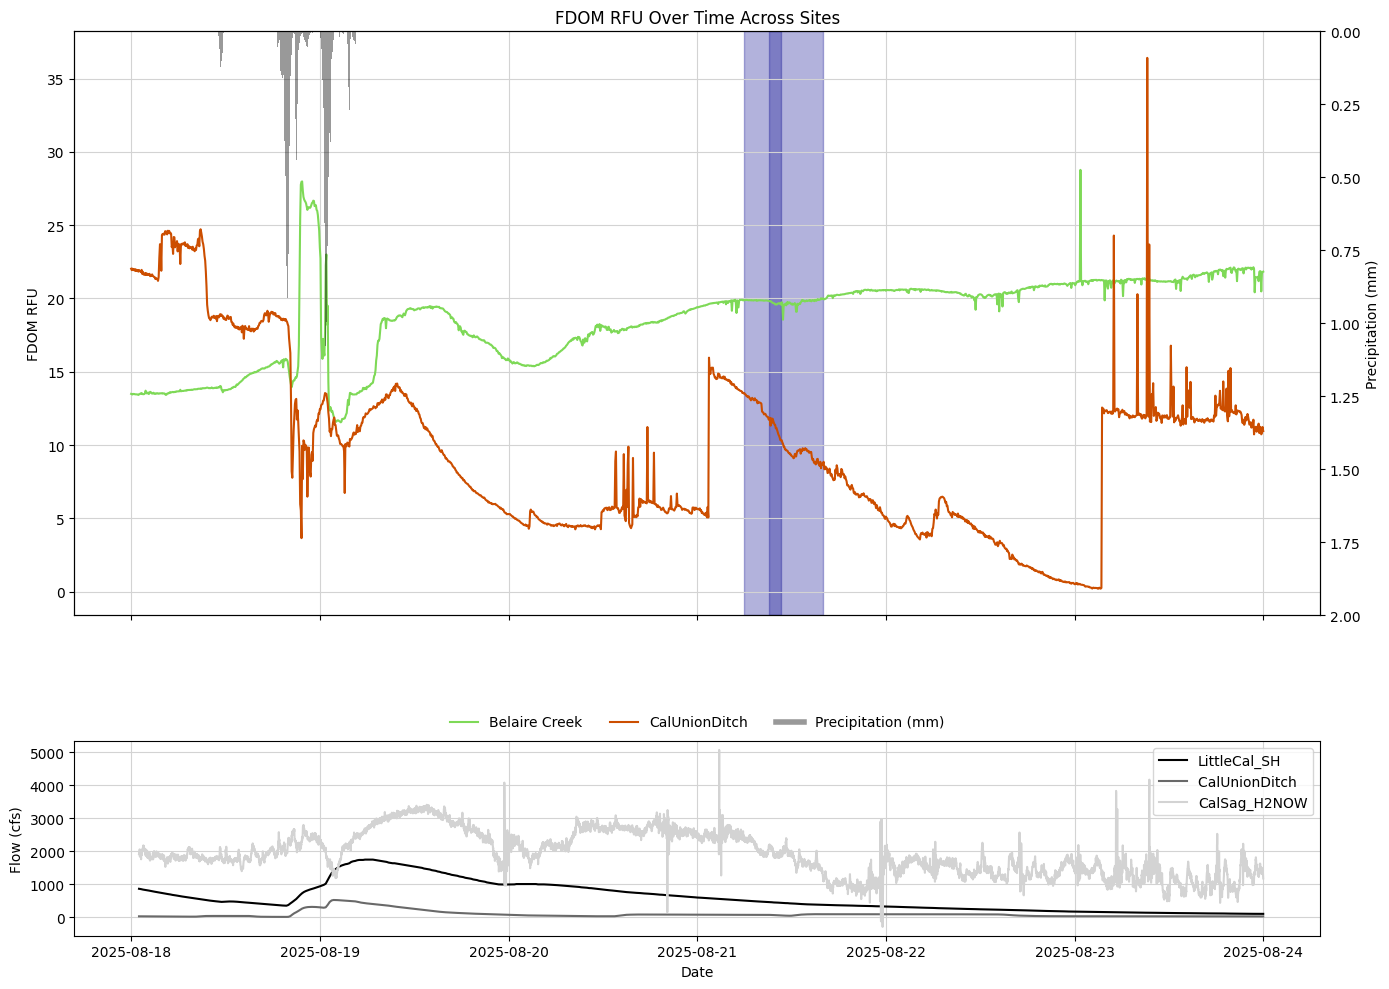

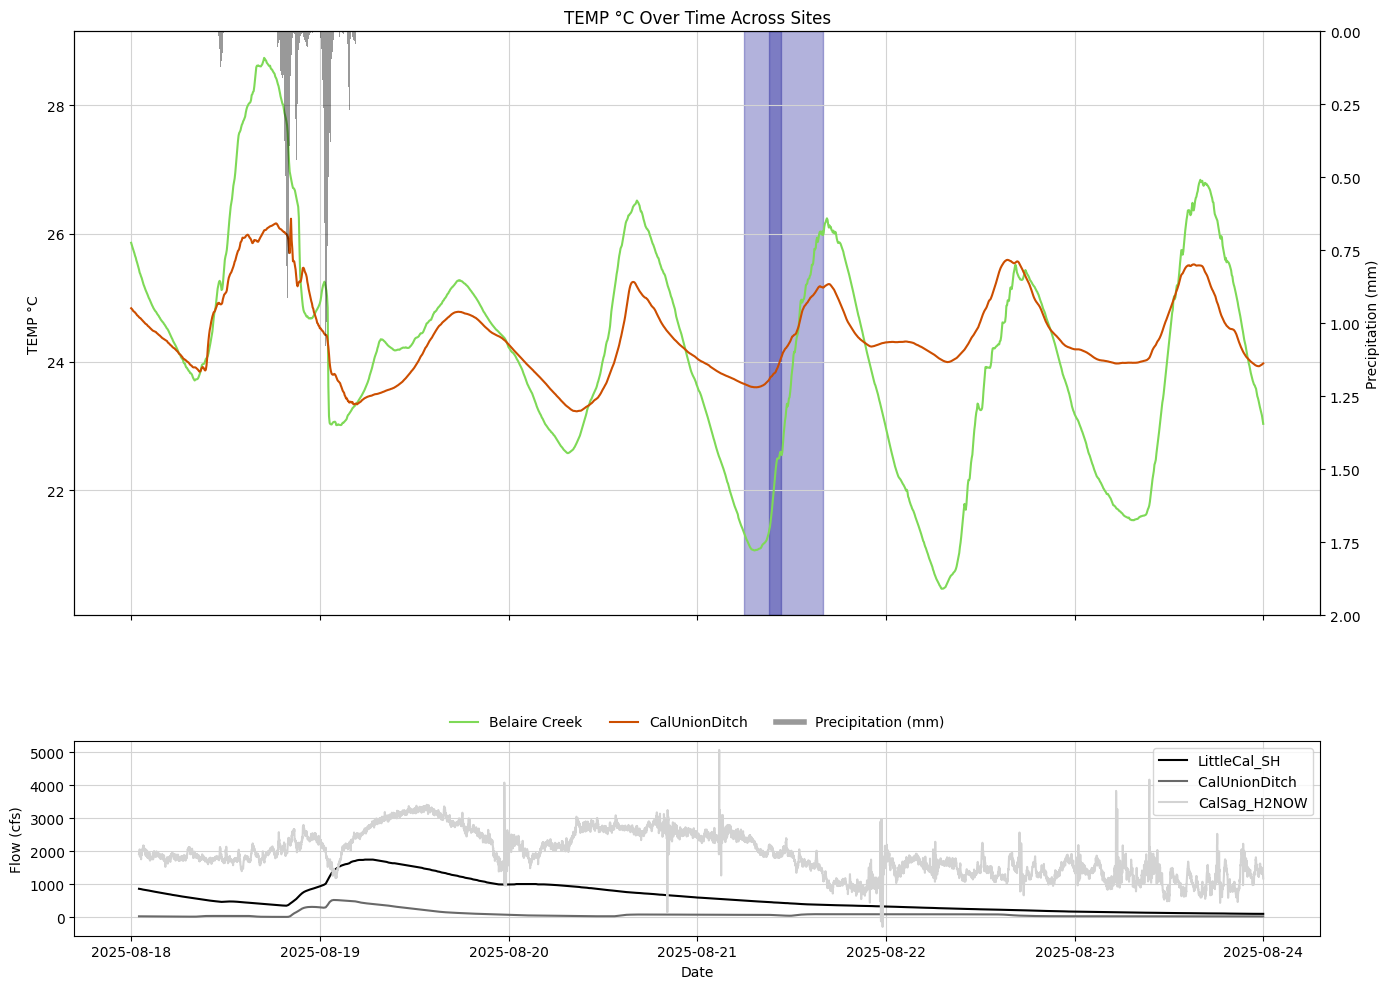

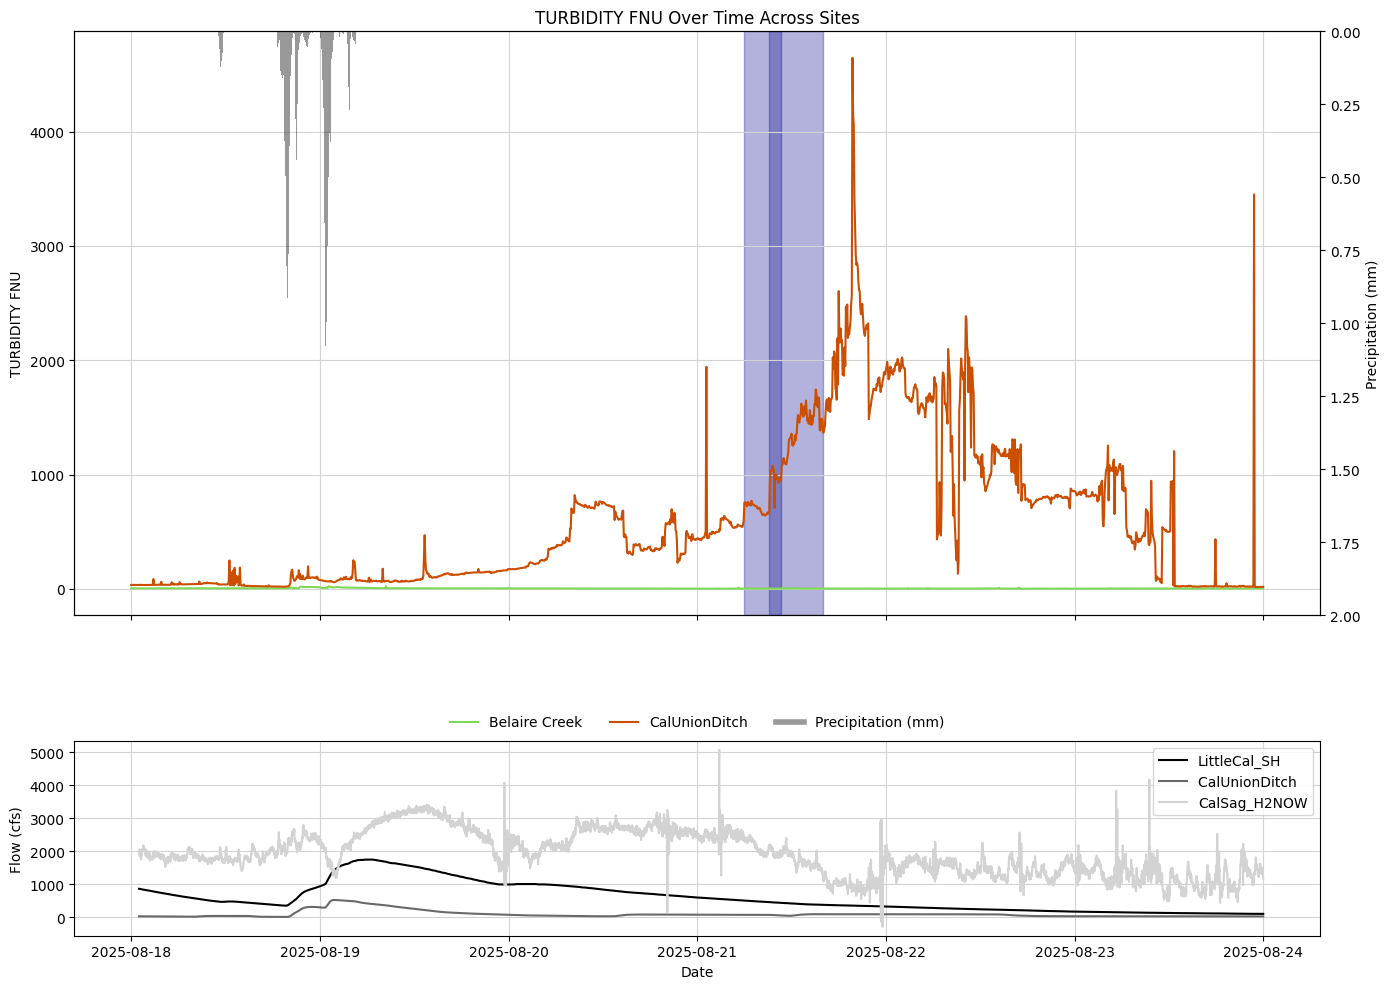

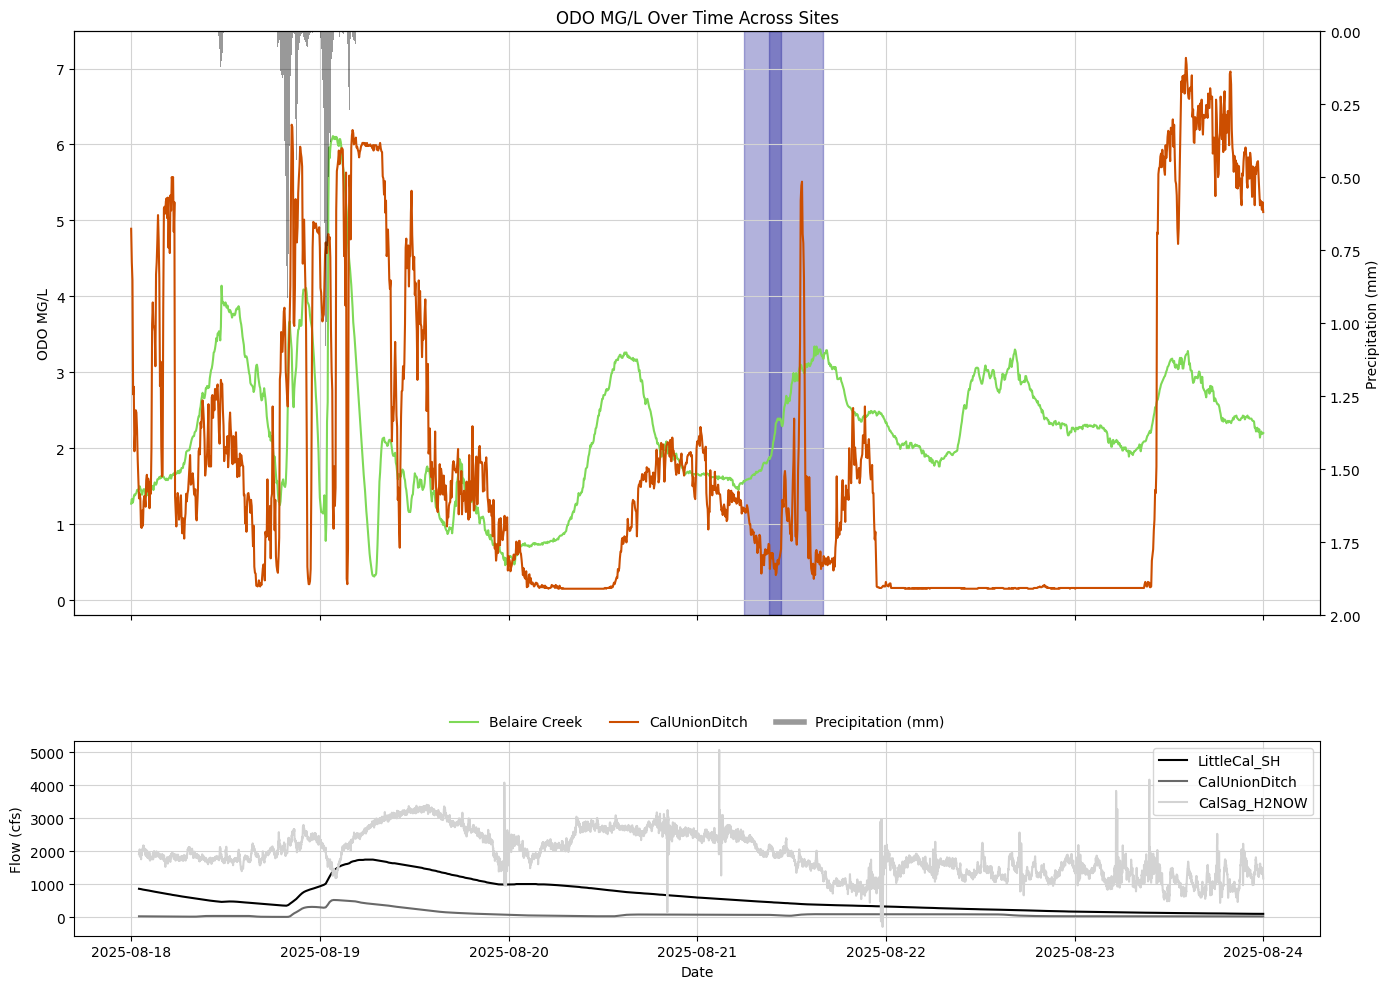

In [ ]:
# Plot data across all sites
for parameter in water_quality_parameters:
    plot_sites_timeseries_all(site_dfs, parameter, precip_df=precipitation, flow_df = flow_data, start_date='2025-08-18', end_date='2025-08-24')